In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import Counter

In [3]:
folders = [
    "outputs",
    "outputs/figures",
    "outputs/tables"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [5]:
df = pd.read_csv("data/medical_text_data.csv")

df.head()

,text,category,clean_text,text_length,word_count
0,I have been experiencing chest discomfort and ...,Symptoms enquiry,i have been experiencing chest discomfort and ...,66,10
1,My child has a high fever and a sore throat.,Symptoms enquiry,my child has a high fever and a sore throat,44,10
2,I feel dizzy and weak most mornings.,Symptoms enquiry,i feel dizzy and weak most mornings,36,7
3,I have a persistent headache and blurred vision.,Symptoms enquiry,i have a persistent headache and blurred vision,48,8
4,I am coughing and my body feels very tired.,Symptoms enquiry,i am coughing and my body feels very tired,43,9


In [7]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nCategory distribution:")
print(df["category"].value_counts())

Dataset shape: (60, 5)

Columns:
Index(['text', 'category', 'clean_text', 'text_length', 'word_count'], dtype='object')

Category distribution:
category
Symptoms enquiry        10
Medication enquiry      10
Chronic care enquiry    10
Medical aid benefits    10
Claims enquiry          10
Emergency guidance      10
Name: count, dtype: int64


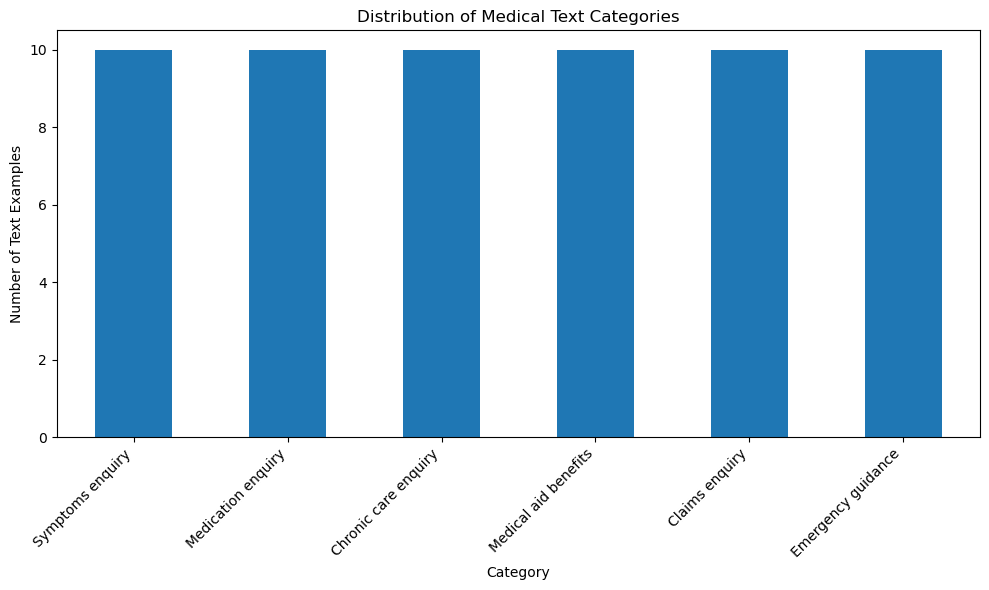

In [9]:
plt.figure(figsize=(10, 6))
df["category"].value_counts().plot(kind="bar")
plt.title("Distribution of Medical Text Categories")
plt.xlabel("Category")
plt.ylabel("Number of Text Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/category_distribution.png", dpi=300)
plt.show()

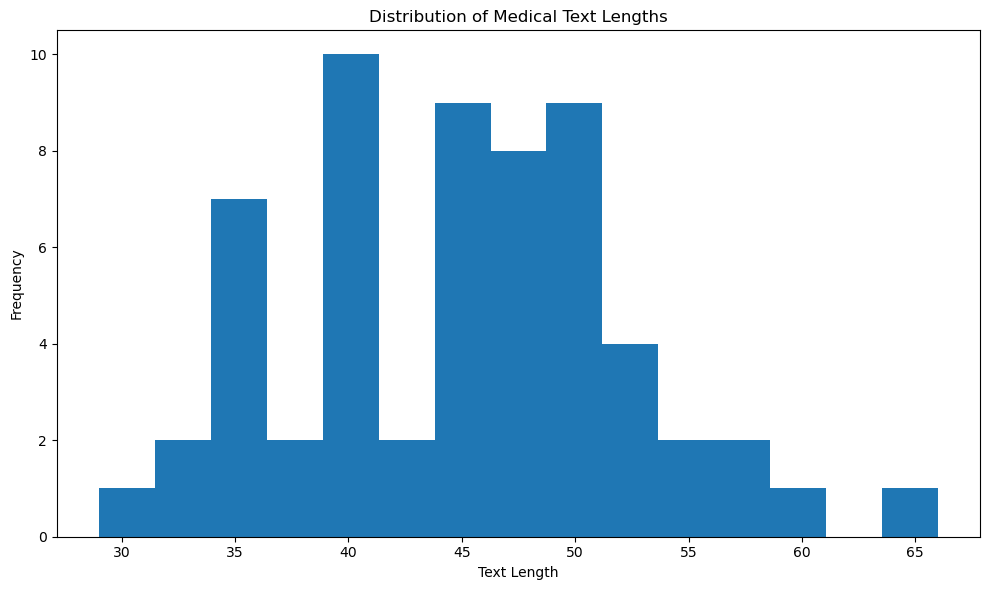

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df["text_length"], bins=15)
plt.title("Distribution of Medical Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("outputs/figures/text_length_distribution.png", dpi=300)
plt.show()

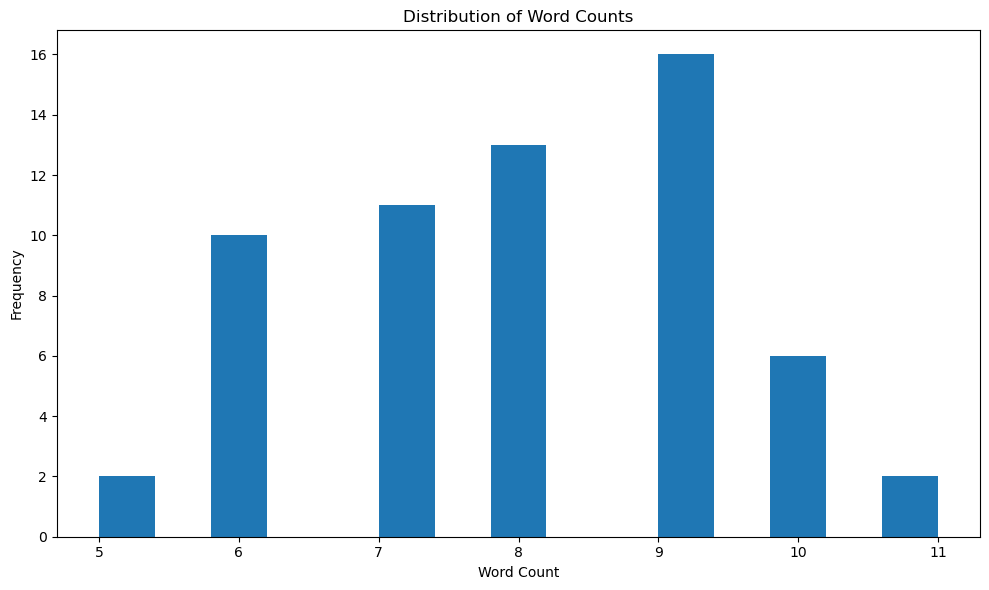

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df["word_count"], bins=15)
plt.title("Distribution of Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("outputs/figures/word_count_distribution.png", dpi=300)
plt.show()

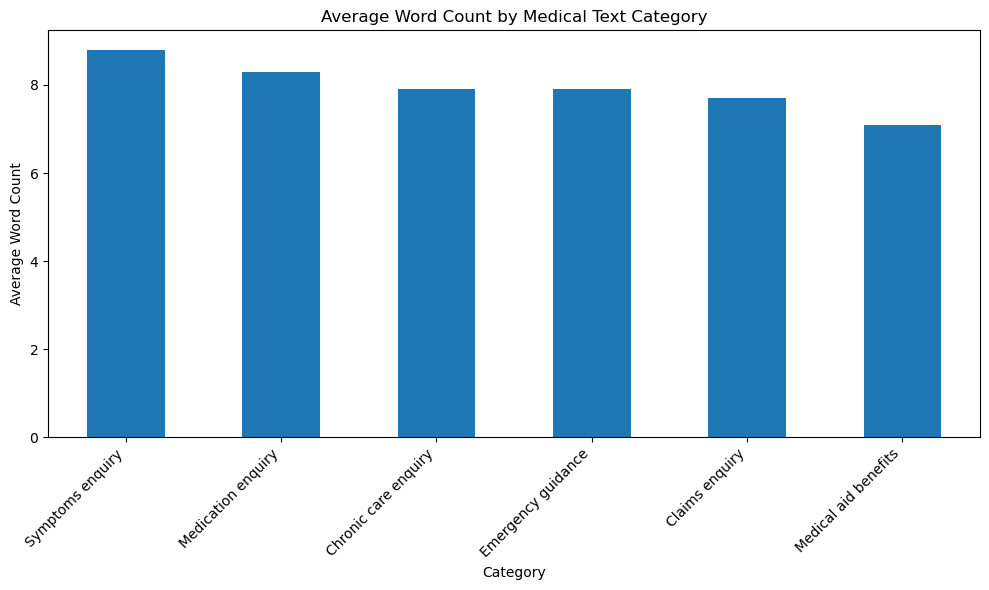

In [15]:
avg_word_count = df.groupby("category")["word_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_word_count.plot(kind="bar")
plt.title("Average Word Count by Medical Text Category")
plt.xlabel("Category")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/average_word_count_by_category.png", dpi=300)
plt.show()

In [17]:
summary_table = df.groupby("category").agg(
    number_of_examples=("text", "count"),
    average_text_length=("text_length", "mean"),
    average_word_count=("word_count", "mean"),
    minimum_word_count=("word_count", "min"),
    maximum_word_count=("word_count", "max")
).reset_index()

summary_table

,category,number_of_examples,average_text_length,average_word_count,minimum_word_count,maximum_word_count
0,Chronic care enquiry,10,46.1,7.9,6,10
1,Claims enquiry,10,41.2,7.7,6,10
2,Emergency guidance,10,47.4,7.9,5,11
3,Medical aid benefits,10,41.8,7.1,5,10
4,Medication enquiry,10,48.4,8.3,7,9
5,Symptoms enquiry,10,44.6,8.8,7,11


In [19]:
summary_table.to_csv("outputs/tables/eda_summary_by_category.csv", index=False)

print("EDA summary table saved successfully.")

EDA summary table saved successfully.


In [21]:
all_words = " ".join(df["clean_text"]).split()

common_words = Counter(all_words).most_common(20)

common_words_df = pd.DataFrame(common_words, columns=["word", "frequency"])

common_words_df

,word,frequency
0,i,41
1,my,34
2,and,12
3,to,12
4,a,11
5,need,11
6,is,10
7,claim,10
8,for,8
9,chronic,8


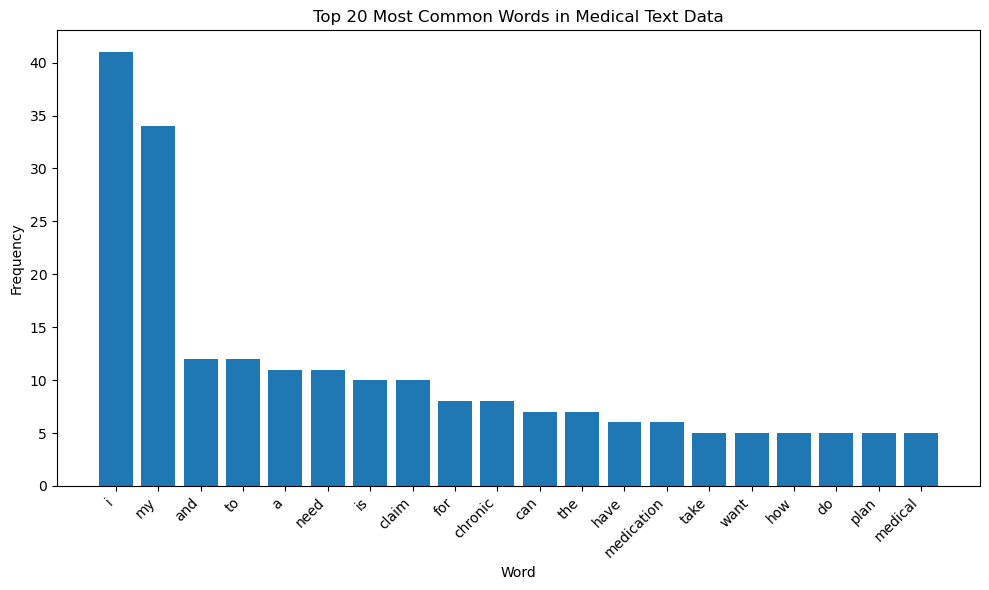

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(common_words_df["word"], common_words_df["frequency"])
plt.title("Top 20 Most Common Words in Medical Text Data")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("outputs/figures/top_20_common_words.png", dpi=300)
plt.show()

In [25]:
common_words_df.to_csv("outputs/tables/top_20_common_words.csv", index=False)

print("Common words table saved successfully.")

Common words table saved successfully.


In [27]:
files_to_check = [
    "outputs/figures/category_distribution.png",
    "outputs/figures/text_length_distribution.png",
    "outputs/figures/word_count_distribution.png",
    "outputs/figures/average_word_count_by_category.png",
    "outputs/figures/top_20_common_words.png",
    "outputs/tables/eda_summary_by_category.csv",
    "outputs/tables/top_20_common_words.csv"
]

for file in files_to_check:
    print(file, "exists:", os.path.exists(file))

outputs/figures/category_distribution.png exists: True
outputs/figures/text_length_distribution.png exists: True
outputs/figures/word_count_distribution.png exists: True
outputs/figures/average_word_count_by_category.png exists: True
outputs/figures/top_20_common_words.png exists: True
outputs/tables/eda_summary_by_category.csv exists: True
outputs/tables/top_20_common_words.csv exists: True
